# 1.3 Lokales Mapping + Optimierung – Schritt für Schritt

**Ausgangslage:** Aus der Visuellen Odometrie (Notebook 1.2) wissen wir, **wie sich die Kamera zwischen zwei Frames bewegt hat** (R und t). Wir kennen aber noch nicht die **3D-Welt**.

**Ziel des lokalen Mappings:** Aus mehreren Frames eine kleine **3D-Punktwolke** erzeugen — die *Landmarks*, die die Kamera gesehen hat.  
**Ziel der lokalen Optimierung:** Kamera-Posen und 3D-Punkte gemeinsam so verschieben, dass die gesamten **Reprojektionsfehler minimal** werden (*Bundle Adjustment*).

**Pipeline:**
```
Mehrere Keyframes
    → Schritt 1: Features extrahieren in allen Keyframes
    → Schritt 2: Features über mehrere Frames hinweg verfolgen (Tracks)
    → Schritt 3: Initialposen schätzen (Essential Matrix + PnP)
    → Schritt 4: Triangulation → 3D-Landmarks erzeugen
    → Schritt 5: Lokale Karte visualisieren
    → Schritt 6: Reprojektionsfehler messen
    → Schritt 7: Bundle Adjustment (lokale Optimierung)
    → Schritt 8: Vergleich vorher / nachher
```

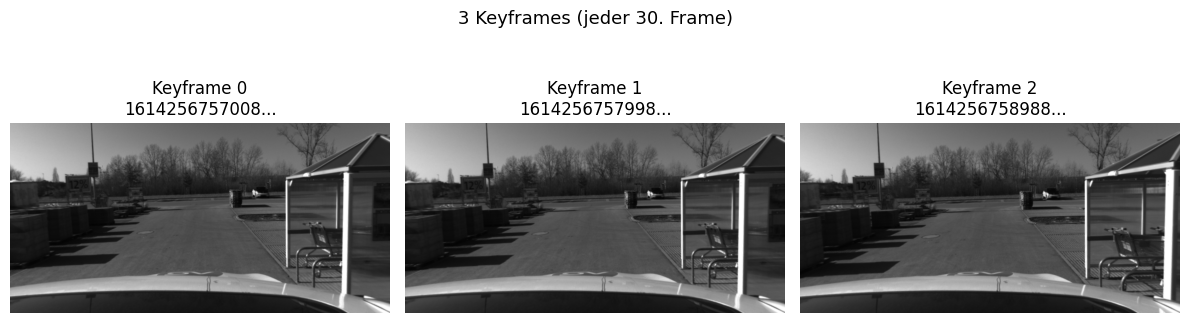

Bildgröße: 800 x 400 Pixel


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.optimize import least_squares
import os

CAM0_ORDNER = "../cam0"

# Wir nehmen Keyframes mit großzügigem Abstand, damit zwischen den
# Aufnahmen genug Parallaxe vorhanden ist. Mit Stride 1 (also direkt
# aufeinanderfolgende Frames) steht die Kamera in unserem Datensatz
# am Anfang fast still — die Essential Matrix wird dann instabil.
STRIDE = 30
ANZAHL_KEYFRAMES = 3

bilder = sorted([f for f in os.listdir(CAM0_ORDNER) if f.endswith('.png')])
keyframe_namen = [bilder[i * STRIDE] for i in range(ANZAHL_KEYFRAMES)]

keyframes_bgr  = [cv2.imread(os.path.join(CAM0_ORDNER, n)) for n in keyframe_namen]
keyframes_rgb  = [cv2.cvtColor(b, cv2.COLOR_BGR2RGB) for b in keyframes_bgr]
keyframes_grau = [cv2.cvtColor(b, cv2.COLOR_BGR2GRAY) for b in keyframes_bgr]

fig, axes = plt.subplots(1, ANZAHL_KEYFRAMES, figsize=(4 * ANZAHL_KEYFRAMES, 4))
for i, (ax, img, name) in enumerate(zip(axes, keyframes_rgb, keyframe_namen)):
    ax.imshow(img)
    ax.set_title(f"Keyframe {i}\n{name[:13]}...")
    ax.axis('off')
plt.suptitle(f"{ANZAHL_KEYFRAMES} Keyframes (jeder {STRIDE}. Frame)", fontsize=13)
plt.tight_layout()
plt.show()

h, w = keyframes_bgr[0].shape[:2]
print(f"Bildgröße: {w} x {h} Pixel")

---
## Schritt 1: Features in allen Keyframes extrahieren

Wie in den vorherigen Notebooks — ORB Features in jedem Keyframe finden.

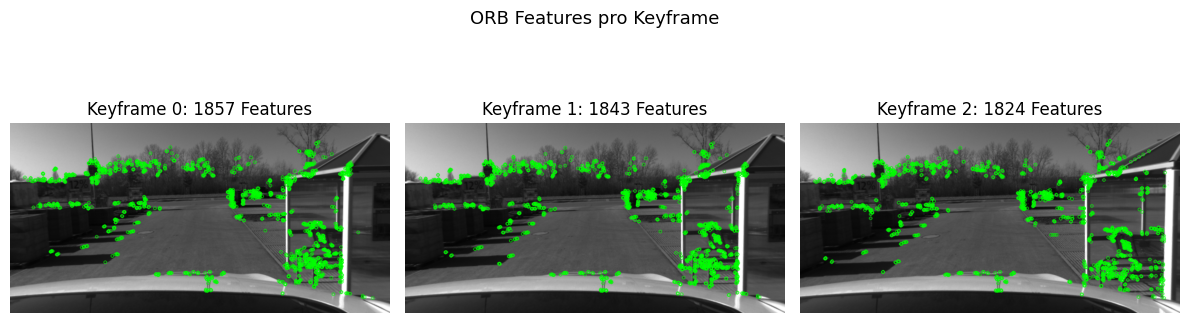

In [2]:
orb = cv2.ORB_create(nfeatures=2000)

alle_kp   = []
alle_desc = []
for grau in keyframes_grau:
    kp, desc = orb.detectAndCompute(grau, None)
    alle_kp.append(kp)
    alle_desc.append(desc)

fig, axes = plt.subplots(1, ANZAHL_KEYFRAMES, figsize=(4 * ANZAHL_KEYFRAMES, 4))
for i, ax in enumerate(axes):
    bild = cv2.drawKeypoints(keyframes_rgb[i], alle_kp[i], None, color=(0, 255, 0))
    ax.imshow(bild)
    ax.set_title(f"Keyframe {i}: {len(alle_kp[i])} Features")
    ax.axis('off')
plt.suptitle("ORB Features pro Keyframe", fontsize=13)
plt.tight_layout()
plt.show()

---
## Schritt 2: Features über mehrere Frames hinweg verfolgen

Im **lokalen Mapping** ist der entscheidende Schritt: dasselbe Feature in **mehreren** Frames wiederfinden.  
Ein Feature, das in Frame 0, 1, 2 und 3 zu sehen ist, gehört zu **einem einzigen 3D-Punkt** — einem **Landmark**.

Wir bauen sogenannte *Tracks* auf:

```
Landmark 17:    Frame 0 (kp 42)  ↔  Frame 1 (kp 88)  ↔  Frame 2 (kp 15)  ↔  Frame 3 (kp 102)
Landmark 18:    Frame 0 (kp 51)  ↔  Frame 1 (kp 73)  ↔  Frame 2 (kp 19)   (nicht in Frame 3)
...
```

Praktisch: wir matchen aufeinanderfolgende Frames (mit Lowe's Ratio Test + Symmetrie-Check) und verketten die Matches zu Tracks.

In [3]:
matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

def matche(desc_a, desc_b, ratio=0.75):
    """Lowe's Ratio Test wie in 1.2 + symmetrischer Check für mehr Robustheit."""
    knn_ab = matcher.knnMatch(desc_a, desc_b, k=2)
    knn_ba = matcher.knnMatch(desc_b, desc_a, k=2)

    gut_ab = {m.queryIdx: m.trainIdx for m, n in knn_ab if m.distance < ratio * n.distance}
    gut_ba = {m.queryIdx: m.trainIdx for m, n in knn_ba if m.distance < ratio * n.distance}

    # symmetrisch: a→b und b→a stimmen überein
    return [(a, b) for a, b in gut_ab.items() if gut_ba.get(b) == a]

# Paarweise Matches zwischen aufeinanderfolgenden Keyframes
paar_matches = []
for i in range(ANZAHL_KEYFRAMES - 1):
    m = matche(alle_desc[i], alle_desc[i + 1])
    paar_matches.append(m)
    print(f"Frame {i} → Frame {i+1}: {len(m)} symmetrische Matches")

# Tracks aufbauen: für jeden Match in (0→1) prüfen, ob er sich in (1→2), ...
# fortsetzen lässt. Ein Track ist eine Liste mit kp-Indizes pro Frame.
lookup = [dict(m) for m in paar_matches]

tracks = []
for start_kp in range(len(alle_kp[0])):
    track = [start_kp]
    aktuell = start_kp
    for i in range(ANZAHL_KEYFRAMES - 1):
        if aktuell in lookup[i]:
            aktuell = lookup[i][aktuell]
            track.append(aktuell)
        else:
            track.append(None)
            aktuell = None
    tracks.append(track)

# Tracks, die in ALLEN Keyframes sichtbar sind, sind besonders wertvoll —
# sie haben die meisten Beobachtungen und werden in der BA stark optimiert.
tracks_voll = [t for t in tracks if all(x is not None for x in t)]

print()
print(f"Gesamt-Tracks geprüft:                          {len(tracks)}")
print(f"Tracks in ALLEN {ANZAHL_KEYFRAMES} Keyframes sichtbar:  {len(tracks_voll)}")
print(f"  → das werden unsere Landmark-Kandidaten")

Frame 0 → Frame 1: 1291 symmetrische Matches
Frame 1 → Frame 2: 500 symmetrische Matches

Gesamt-Tracks geprüft:                          1857
Tracks in ALLEN 3 Keyframes sichtbar:  406
  → das werden unsere Landmark-Kandidaten


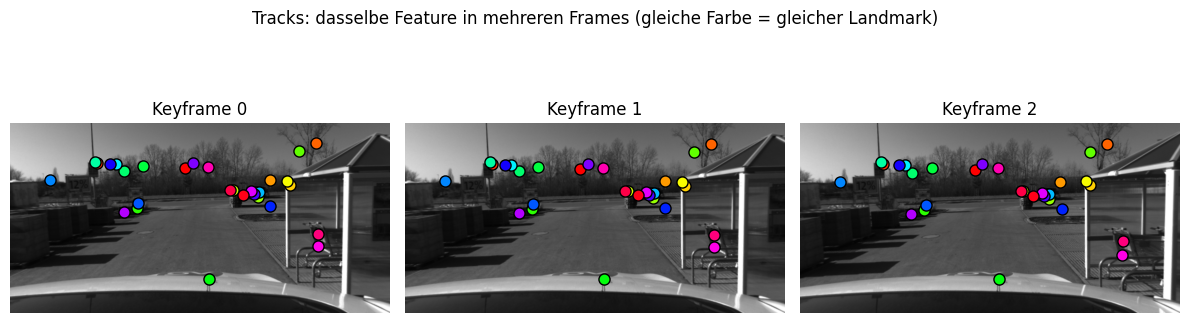

In [4]:
# Visualisierung: ein paar Tracks bunt über alle Keyframes hinweg zeichnen
import matplotlib.cm as cm

fig, axes = plt.subplots(1, ANZAHL_KEYFRAMES, figsize=(4 * ANZAHL_KEYFRAMES, 4))
for ax, img, kfi in zip(axes, keyframes_rgb, range(ANZAHL_KEYFRAMES)):
    ax.imshow(img)
    ax.set_title(f"Keyframe {kfi}")
    ax.axis('off')

rng = np.random.default_rng(42)
auswahl = rng.choice(len(tracks_voll), size=min(30, len(tracks_voll)), replace=False)
farben = cm.hsv(np.linspace(0, 1, len(auswahl)))

for farbe, idx in zip(farben, auswahl):
    t = tracks_voll[idx]
    for kfi, kp_idx in enumerate(t):
        x, y = alle_kp[kfi][kp_idx].pt
        axes[kfi].plot(x, y, 'o', markersize=8, color=farbe, markeredgecolor='black')

plt.suptitle("Tracks: dasselbe Feature in mehreren Frames (gleiche Farbe = gleicher Landmark)", fontsize=12)
plt.tight_layout()
plt.show()

---
## Schritt 3: Initialposen der Kameras schätzen

**Wichtig:** Im Mono-SLAM ist der absolute Maßstab nicht beobachtbar. Wir lösen das mit der Standard-Strategie:

1. **Kamera 0** sitzt im Ursprung (Welt-Koordinatensystem definiert).
2. **Kamera 1** wird per **Essential Matrix** aus Paar (0, 1) bestimmt — die Translation hat dabei willkürlich Länge 1. **Damit ist der Maßstab fixiert.**
3. Die ersten 3D-Landmarks werden trianguliert (sie haben damit denselben Maßstab).
4. Alle weiteren Kameras werden per **PnP** ([Perspective-n-Point](https://docs.opencv.org/4.x/d5/d1f/calib3d_solvePnP.html)) gegen die bereits existierenden 3D-Punkte bestimmt — **das behält den Maßstab konsistent**, während ein neues Essential-Matrix-Paar das nicht könnte (jedes Paar hätte einen eigenen unbekannten Maßstab).

In [5]:
# Geschätzte Kamera-Kalibrierung (wie in 1.2)
fx = w * 0.8
fy = w * 0.8
cx = w / 2
cy = h / 2
K = np.array([[fx,  0, cx],
              [ 0, fy, cy],
              [ 0,  0,  1]], dtype=np.float64)

print("Kamera-Matrix K:")
print(f"  fx={fx:.1f}  fy={fy:.1f}  cx={cx:.1f}  cy={cy:.1f}")
print()

# ── Kamera 0: Ursprung ───────────────────────────────────────────────
kam_R = [np.eye(3)]
kam_t = [np.zeros((3, 1))]

# ── Kamera 1: Essential Matrix aus Paar (0, 1) ───────────────────────
matches01 = paar_matches[0]
p0 = np.float32([alle_kp[0][a].pt for a, b in matches01])
p1 = np.float32([alle_kp[1][b].pt for a, b in matches01])

E, _ = cv2.findEssentialMat(p0, p1, K, method=cv2.RANSAC, prob=0.999, threshold=1.0)
_, R1, t1, _ = cv2.recoverPose(E, p0, p1, K)
kam_R.append(R1)
kam_t.append(t1)

print(f"Kamera 1 (aus Essential Matrix):  t = [{t1[0,0]:+.3f}, {t1[1,0]:+.3f}, {t1[2,0]:+.3f}]")
print(f"   → Maßstab nun fixiert auf ||t1|| = {np.linalg.norm(t1):.3f}")

Kamera-Matrix K:
  fx=640.0  fy=640.0  cx=400.0  cy=200.0

Kamera 1 (aus Essential Matrix):  t = [+0.053, -0.145, +0.988]
   → Maßstab nun fixiert auf ||t1|| = 1.000


In [6]:
# Initial-Triangulation aus Paar (0, 1) — nur für Tracks, die in allen
# Keyframes sichtbar sind (damit wir sie später per PnP wiederfinden).
P0 = K @ np.hstack([kam_R[0], kam_t[0]])
P1 = K @ np.hstack([kam_R[1], kam_t[1]])

pts0 = np.float32([alle_kp[0][t[0]].pt for t in tracks_voll])
pts1 = np.float32([alle_kp[1][t[1]].pt for t in tracks_voll])

# OpenCV triangulatePoints → homogene Koordinaten
X_h = cv2.triangulatePoints(P0, P1, pts0.T, pts1.T)
X_init = (X_h[:3] / X_h[3]).T

# Sanity-Filter: Punkte müssen vor beiden Kameras liegen und endliche Tiefe haben
Z_MAX = 500  # in Einheiten von ||t1|| (Mono-Skalierung)

def tiefe_in_cam(X, R, t):
    return (R @ X.T + t).T[:, 2]

tiefe0 = tiefe_in_cam(X_init, kam_R[0], kam_t[0])
tiefe1 = tiefe_in_cam(X_init, kam_R[1], kam_t[1])
valide = (tiefe0 > 0) & (tiefe1 > 0) & np.all(np.isfinite(X_init), axis=1) & (tiefe0 < Z_MAX)

X_init = X_init[valide]
tracks_aktiv = [t for t, ok in zip(tracks_voll, valide) if ok]

print(f"Initiale Triangulation (Paar 0-1): {len(X_init)} 3D-Punkte vor beiden Kameras")
print(f"Tiefenbereich (Kamera 1):  {tiefe1[valide].min():.2f}  …  {tiefe1[valide].max():.2f}")

Initiale Triangulation (Paar 0-1): 146 3D-Punkte vor beiden Kameras
Tiefenbereich (Kamera 1):  24.99  …  500.65


In [7]:
# ── Kameras 2, 3, ... : PnP gegen die existierenden 3D-Punkte ────────
# Für jede weitere Kamera schrumpft tracks_aktiv um die PnP-Outlier.
for k in range(2, ANZAHL_KEYFRAMES):
    img_pts = np.float32([alle_kp[k][t[k]].pt for t in tracks_aktiv])
    ok, rvec, tvec, inliers = cv2.solvePnPRansac(
        X_init, img_pts, K, distCoeffs=None,
        reprojectionError=4.0, confidence=0.999, iterationsCount=200
    )
    assert ok, f"PnP für Kamera {k} fehlgeschlagen"
    R_k, _ = cv2.Rodrigues(rvec)
    kam_R.append(R_k)
    kam_t.append(tvec.reshape(3, 1))
    print(f"Kamera {k} (PnP): {len(inliers)} / {len(X_init)} Inlier")

    # Outlier entfernen — Punkte, die nicht zu Kamera k passen, fliegen raus
    msk = np.zeros(len(tracks_aktiv), dtype=bool)
    msk[inliers.ravel()] = True
    tracks_aktiv = [t for t, ok in zip(tracks_aktiv, msk) if ok]
    X_init       = X_init[msk]

print()
print("Kamera-Positionen (Welt-Koordinaten):")
for i, (R, t) in enumerate(zip(kam_R, kam_t)):
    pos = -R.T @ t
    print(f"  Kamera {i}: ({pos[0,0]:+.3f}, {pos[1,0]:+.3f}, {pos[2,0]:+.3f})")
print()
print(f"Aktive Landmarks für lokales Mapping: {len(X_init)}")

Kamera 2 (PnP): 132 / 146 Inlier

Kamera-Positionen (Welt-Koordinaten):
  Kamera 0: (+0.000, +0.000, +0.000)
  Kamera 1: (-0.054, +0.147, -0.988)
  Kamera 2: (-0.139, +0.045, -0.974)

Aktive Landmarks für lokales Mapping: 132


---
## Schritt 4: Triangulation — die Mathematik dahinter

Jetzt wo wir die Kamera-Posen kennen, können wir die 3D-Punkte sauber bestimmen. Für jeden Track haben wir:
- die **2D-Pixel-Position** des Features in mehreren Frames
- die zugehörigen **Kamera-Posen**

Geometrisch: man schickt einen **Sehstrahl** von jeder Kamera durch den Pixel — die Strahlen schneiden sich (idealerweise) im 3D-Punkt.

$$x_i \;\;\sim\;\; P_i \, X \qquad \text{(Pixel} \sim \text{Projektionsmatrix} \cdot \text{3D-Punkt)}$$

Aus dieser Gleichung lassen sich zwei lineare Bedingungen pro Beobachtung ableiten (Kreuzprodukt):

$$\begin{aligned} x \cdot P_i^{(3)} \, X &= P_i^{(1)} \, X \\ y \cdot P_i^{(3)} \, X &= P_i^{(2)} \, X \end{aligned}$$

Mit $N$ Beobachtungen entsteht ein $2N \times 4$ Gleichungssystem $A\,X = 0$. Die Lösung ist der rechte Singulärvektor zum kleinsten Singulärwert (**DLT**). Wir nutzen das jetzt um *alle* aktiven Landmarks mit *allen* Beobachtungen (Frame 0, 1, 2, 3) sauber zu re-triangulieren.

In [8]:
def triangulate_multi(track, kp_pro_frame, P_listen):
    """DLT-Triangulation für einen Track mit beliebig vielen Beobachtungen."""
    A = []
    for kfi, kp_idx in enumerate(track):
        if kp_idx is None:
            continue
        x, y = kp_pro_frame[kfi][kp_idx].pt
        P = P_listen[kfi]
        A.append(x * P[2] - P[0])
        A.append(y * P[2] - P[1])
    A = np.array(A)
    _, _, Vt = np.linalg.svd(A)
    X_h = Vt[-1]
    return X_h[:3] / X_h[3]

# Projektionsmatrizen aus den aktuellen Posen
P = [K @ np.hstack([R, t]) for R, t in zip(kam_R, kam_t)]

landmarks = np.array([triangulate_multi(t, alle_kp, P) for t in tracks_aktiv])

# Nochmaliger Filter: vor allen Kameras + plausible Tiefe
valide = np.ones(len(landmarks), dtype=bool)
for R, t in zip(kam_R, kam_t):
    z = (R @ landmarks.T + t).T[:, 2]
    valide &= (z > 0) & (z < Z_MAX)
valide &= np.all(np.isfinite(landmarks), axis=1)

landmarks    = landmarks[valide]
tracks_aktiv = [t for t, ok in zip(tracks_aktiv, valide) if ok]

print(f"Triangulierte 3D-Landmarks ({ANZAHL_KEYFRAMES}-View DLT): {len(landmarks)}")
print(f"Statistiken:")
print(f"  X: {landmarks[:,0].min():+.2f}  …  {landmarks[:,0].max():+.2f}")
print(f"  Y: {landmarks[:,1].min():+.2f}  …  {landmarks[:,1].max():+.2f}")
print(f"  Z: {landmarks[:,2].min():+.2f}  …  {landmarks[:,2].max():+.2f}  (Tiefe)")

Triangulierte 3D-Landmarks (3-View DLT): 108
Statistiken:
  X: -177.12  …  +13.14
  Y: -85.96  …  +68.92
  Z: +17.99  …  +478.73  (Tiefe)


---
## Schritt 5: Die lokale Karte visualisieren

Jetzt sehen wir, was wir gerade aufgebaut haben: eine **kleine 3D-Punktwolke** (Landmarks) und die **Posen der Kameras**, die diese Punkte gesehen haben.  
Das ist die *lokale Karte*. Die kleinen Pyramiden zeigen die Kameras (Spitze = Zentrum, geöffnet in Sichtrichtung).

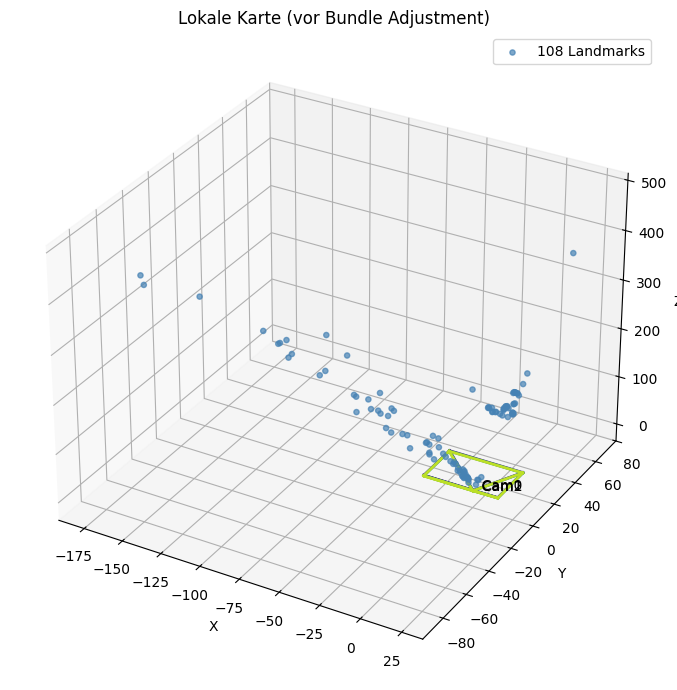

In [9]:
def kamera_pyramide(R, t, skala=0.2):
    """Pyramide für eine Kamera in Weltkoordinaten."""
    spitze = np.array([0, 0, 0])
    ecken  = np.array([
        [-1, -0.5, 1.5],
        [ 1, -0.5, 1.5],
        [ 1,  0.5, 1.5],
        [-1,  0.5, 1.5],
    ]) * skala
    # Kamera → Welt: X_welt = R^T (X_kam - t)
    def k2w(P):
        return R.T @ (P - t.ravel())
    spitze_w = k2w(spitze)
    ecken_w  = np.array([k2w(e) for e in ecken])
    linien = [(spitze_w, e) for e in ecken_w]
    for i in range(4):
        linien.append((ecken_w[i], ecken_w[(i+1) % 4]))
    return linien

def plot_karte(landmarks, kam_R, kam_t, titel, ax=None, kam_skala=None):
    if ax is None:
        fig = plt.figure(figsize=(9, 7))
        ax = fig.add_subplot(111, projection='3d')
    if kam_skala is None:
        # automatische Skalierung anhand der Szenenausdehnung
        spann = np.ptp(landmarks, axis=0).max()
        kam_skala = max(spann * 0.05, 0.5)
    ax.scatter(landmarks[:, 0], landmarks[:, 1], landmarks[:, 2],
               c='steelblue', s=14, alpha=0.7, label=f'{len(landmarks)} Landmarks')
    farben_kam = plt.cm.viridis(np.linspace(0.1, 0.9, len(kam_R)))
    for i, (R, t, farbe) in enumerate(zip(kam_R, kam_t, farben_kam)):
        for a, b in kamera_pyramide(R, t, skala=kam_skala):
            ax.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]],
                    color=farbe, linewidth=2)
        pos = -R.T @ t
        ax.text(pos[0,0], pos[1,0], pos[2,0], f"  Cam{i}", color='black', fontsize=10)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(titel)
    ax.legend()
    return ax

plot_karte(landmarks, kam_R, kam_t, 'Lokale Karte (vor Bundle Adjustment)')
plt.tight_layout()
plt.show()

---
## Schritt 6: Reprojektionsfehler messen

Wir haben jetzt:
- 3D-Punkte $X_j$ (Landmarks)
- Kamera-Posen $(R_i, t_i)$
- die echten Pixel-Beobachtungen $x_{ij}$ in jedem Frame

Wenn alles **perfekt** wäre, würde der 3D-Punkt $X_j$ projeziert durch Kamera $i$ **genau** auf den beobachteten Pixel $x_{ij}$ fallen. Das ist nicht der Fall — es gibt einen **Reprojektionsfehler**:

$$r_{ij} \;=\; x_{ij} \;-\; \pi\!\big(K\,(R_i X_j + t_i)\big)$$

wobei $\pi(\cdot)$ die Division durch die Tiefe ist (Lochkamera-Modell). Quellen des Fehlers: Rauschen in der Feature-Detection, ungenaue K-Matrix, Drift aus VO/PnP.

Die Bundle Adjustment minimiert die Summe aller quadrierten Reprojektionsfehler:

$$\min_{\{R_i, t_i\}, \{X_j\}} \;\; \sum_{i,j} \;\big\| x_{ij} - \pi(K(R_i X_j + t_i)) \big\|^2$$

Anzahl Beobachtungen:        324
Mittlerer Pixel-Fehler:      0.375 px
Median Pixel-Fehler:         0.277 px
Maximaler Pixel-Fehler:      1.982 px


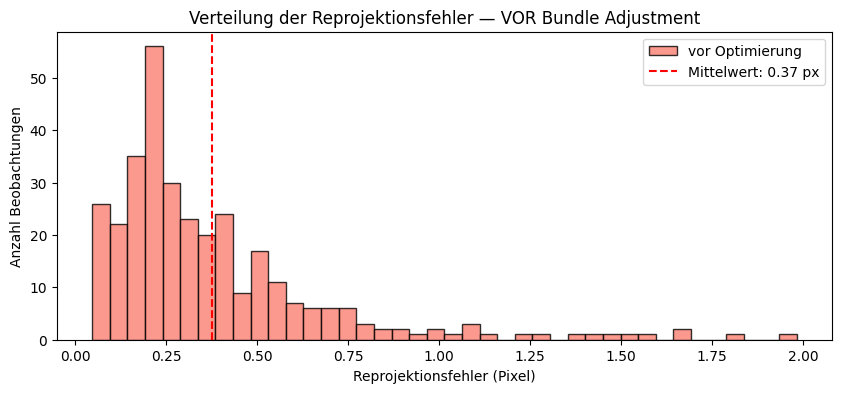

In [10]:
def projiziere(X, R, t, K):
    X_cam = R @ X + t.ravel()
    x_h = K @ X_cam
    return x_h[:2] / x_h[2]

def alle_residuen(landmarks, tracks, kam_R, kam_t, kp_pro_frame, K):
    res = []
    for X, tr in zip(landmarks, tracks):
        for kfi, kp_idx in enumerate(tr):
            if kp_idx is None:
                continue
            beob = np.array(kp_pro_frame[kfi][kp_idx].pt)
            res.append(beob - projiziere(X, kam_R[kfi], kam_t[kfi], K))
    return np.array(res)

res_vorher = alle_residuen(landmarks, tracks_aktiv, kam_R, kam_t, alle_kp, K)
norm_vorher = np.linalg.norm(res_vorher, axis=1)

print(f"Anzahl Beobachtungen:        {len(res_vorher)}")
print(f"Mittlerer Pixel-Fehler:      {norm_vorher.mean():.3f} px")
print(f"Median Pixel-Fehler:         {np.median(norm_vorher):.3f} px")
print(f"Maximaler Pixel-Fehler:      {norm_vorher.max():.3f} px")

plt.figure(figsize=(10, 4))
plt.hist(norm_vorher, bins=40, color='salmon', edgecolor='black', alpha=0.8, label='vor Optimierung')
plt.axvline(norm_vorher.mean(), color='red', linestyle='--', label=f'Mittelwert: {norm_vorher.mean():.2f} px')
plt.xlabel('Reprojektionsfehler (Pixel)')
plt.ylabel('Anzahl Beobachtungen')
plt.title('Verteilung der Reprojektionsfehler — VOR Bundle Adjustment')
plt.legend()
plt.show()

---
## Schritt 7: Bundle Adjustment — lokale Optimierung

Jetzt der Kern des lokalen Mappings: alle Kamera-Posen (außer Kamera 0, die wir fixieren, damit das Problem überhaupt eindeutig wird) und alle 3D-Punkte werden gemeinsam so verschoben, dass die Reprojektionsfehler insgesamt minimal sind.

**Wichtig:**
- Kamera 0 wird **fixiert** (Welt-Ursprung).
- Rotationen werden als 3D-**Rotationsvektoren** (Rodrigues) optimiert — das sind nur 3 Parameter pro Kamera.
- Der Solver: **`scipy.optimize.least_squares`** mit `method='lm'` (Levenberg-Marquardt) — dasselbe Verfahren, das auch g2o / Ceres in echten SLAM-Systemen einsetzen, nur in didaktischer Mini-Variante.

In [11]:
# Parameter-Vektor packen:
#   [rvec_1, tvec_1, rvec_2, tvec_2, ..., X_0, X_1, ...]
# Kamera 0 ist fixiert und NICHT im Vektor.

N_KAM = ANZAHL_KEYFRAMES
N_LM  = len(landmarks)

def packe(kam_R, kam_t, landmarks):
    teile = []
    for i in range(1, N_KAM):
        rvec, _ = cv2.Rodrigues(kam_R[i])
        teile.append(rvec.ravel())
        teile.append(kam_t[i].ravel())
    teile.append(landmarks.ravel())
    return np.concatenate(teile)

def entpacke(params):
    Rs = [np.eye(3)]
    ts = [np.zeros((3, 1))]
    off = 0
    for i in range(1, N_KAM):
        rvec = params[off:off+3]; off += 3
        tvec = params[off:off+3]; off += 3
        R, _ = cv2.Rodrigues(rvec)
        Rs.append(R)
        ts.append(tvec.reshape(3, 1))
    pts = params[off:].reshape(-1, 3)
    return Rs, ts, pts

# Beobachtungs-Tabelle: welche Beob. gehört zu welchem Punkt + Frame
beob_idx_kam = []
beob_idx_pt  = []
beob_xy      = []
for j, tr in enumerate(tracks_aktiv):
    for kfi, kp_idx in enumerate(tr):
        if kp_idx is None:
            continue
        beob_idx_kam.append(kfi)
        beob_idx_pt.append(j)
        beob_xy.append(alle_kp[kfi][kp_idx].pt)
beob_idx_kam = np.array(beob_idx_kam)
beob_idx_pt  = np.array(beob_idx_pt)
beob_xy      = np.array(beob_xy)

def residuen_fn(params):
    Rs, ts, pts = entpacke(params)
    res = np.empty((len(beob_xy), 2))
    for k in range(len(beob_xy)):
        i = beob_idx_kam[k]
        j = beob_idx_pt[k]
        X_cam = Rs[i] @ pts[j] + ts[i].ravel()
        x_h = K @ X_cam
        proj = x_h[:2] / x_h[2]
        res[k] = beob_xy[k] - proj
    return res.ravel()

x0 = packe(kam_R, kam_t, landmarks)
print(f"Anzahl Parameter: {len(x0)}")
print(f"   = {N_KAM-1} Kameras × 6  +  {N_LM} Punkte × 3")
print(f"Anzahl Residuen:  {len(beob_xy) * 2}")
print()
print("Starte Bundle Adjustment...")

ergebnis = least_squares(residuen_fn, x0, method='trf', loss='linear', max_nfev=200, xtol=1e-10, ftol=1e-10, verbose=1)

kam_R_opt, kam_t_opt, landmarks_opt = entpacke(ergebnis.x)
landmarks_opt = np.array(landmarks_opt)

print()
print(f"Kosten vorher:  {0.5 * np.sum(residuen_fn(x0)**2):.4f}")
print(f"Kosten nachher: {ergebnis.cost:.4f}")

Anzahl Parameter: 336
   = 2 Kameras × 6  +  108 Punkte × 3
Anzahl Residuen:  648

Starte Bundle Adjustment...
`ftol` termination condition is satisfied.
Function evaluations 92, initial cost 3.8310e+01, final cost 2.9360e+01, first-order optimality 7.57e-02.

Kosten vorher:  38.3099
Kosten nachher: 29.3597


---
## Schritt 8: Vergleich — vorher vs. nachher

Zwei Vergleiche:
1. **Reprojektionsfehler** — sollte deutlich kleiner werden.
2. **3D-Karte** — sollte aufgeräumter aussehen (Punkte enger zusammen, Kameras besser ausgerichtet).

Reprojektionsfehler — Vergleich
--------------------------------------------------
                             vorher    nachher
Mittlerer Fehler (px):      0.375      0.308
Median (px):                0.277      0.213
Maximum (px):               1.982      2.000


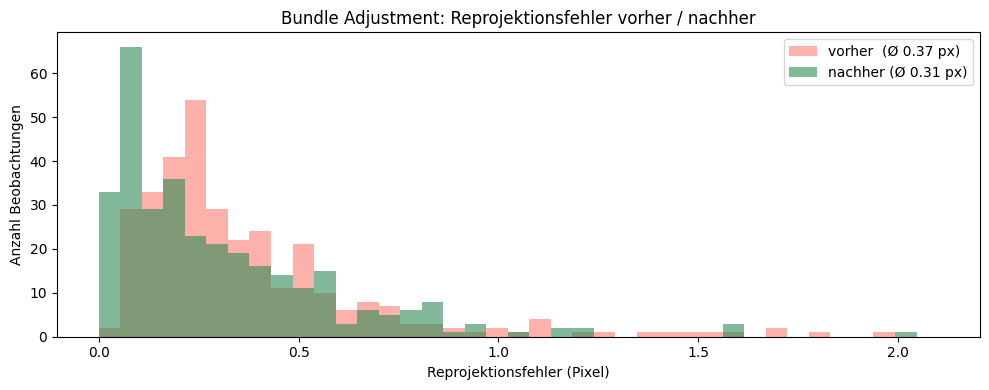

In [12]:
res_nachher  = alle_residuen(landmarks_opt, tracks_aktiv, kam_R_opt, kam_t_opt, alle_kp, K)
norm_nachher = np.linalg.norm(res_nachher, axis=1)

print("Reprojektionsfehler — Vergleich")
print("-" * 50)
print(f"{'':25s}    vorher    nachher")
print(f"Mittlerer Fehler (px):   {norm_vorher.mean():8.3f}   {norm_nachher.mean():8.3f}")
print(f"Median (px):             {np.median(norm_vorher):8.3f}   {np.median(norm_nachher):8.3f}")
print(f"Maximum (px):            {norm_vorher.max():8.3f}   {norm_nachher.max():8.3f}")

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
bins = np.linspace(0, max(norm_vorher.max(), norm_nachher.max()) * 1.05, 40)
ax.hist(norm_vorher,  bins=bins, color='salmon',   alpha=0.6, label=f'vorher  (Ø {norm_vorher.mean():.2f} px)')
ax.hist(norm_nachher, bins=bins, color='seagreen', alpha=0.6, label=f'nachher (Ø {norm_nachher.mean():.2f} px)')
ax.set_xlabel('Reprojektionsfehler (Pixel)')
ax.set_ylabel('Anzahl Beobachtungen')
ax.set_title('Bundle Adjustment: Reprojektionsfehler vorher / nachher')
ax.legend()
plt.tight_layout()
plt.show()

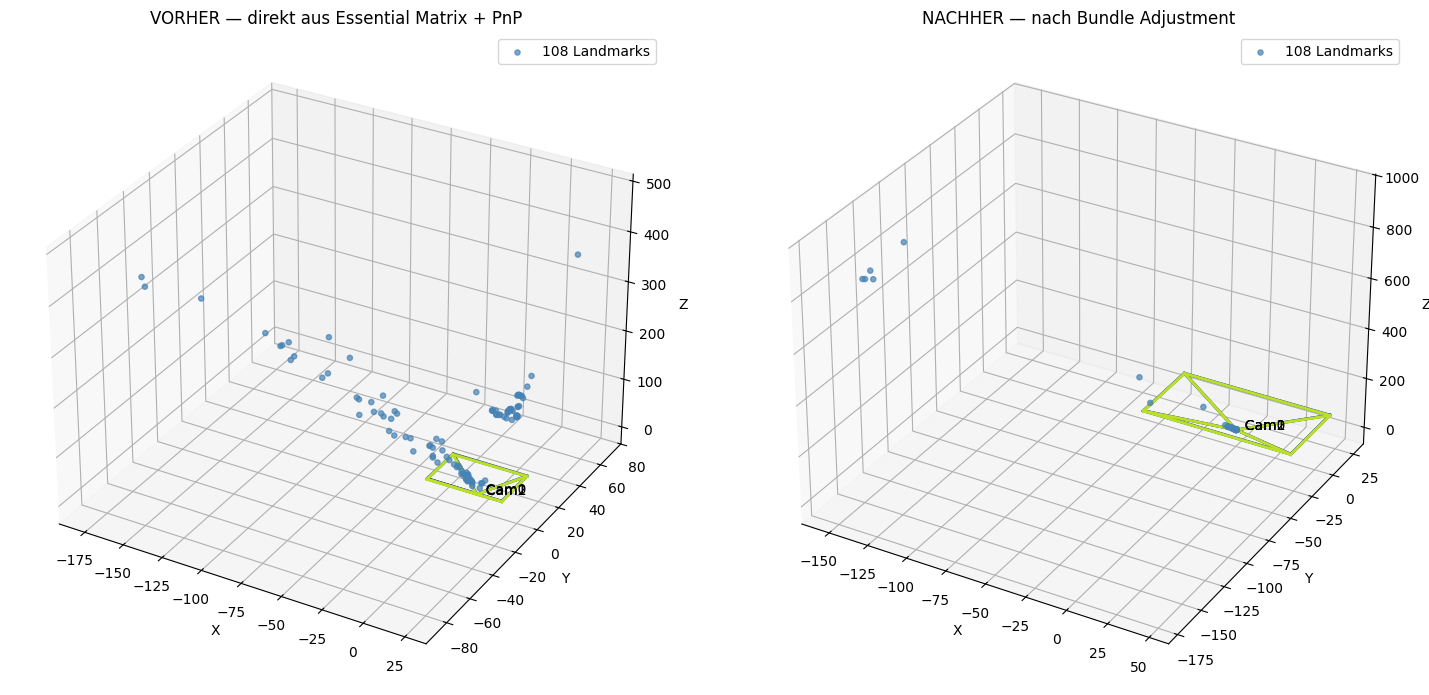

In [13]:
fig = plt.figure(figsize=(15, 7))
ax1 = fig.add_subplot(121, projection='3d')
plot_karte(landmarks,     kam_R,     kam_t,     'VORHER — direkt aus Essential Matrix + PnP', ax=ax1)
ax2 = fig.add_subplot(122, projection='3d')
plot_karte(landmarks_opt, kam_R_opt, kam_t_opt, 'NACHHER — nach Bundle Adjustment',           ax=ax2)
plt.tight_layout()
plt.show()

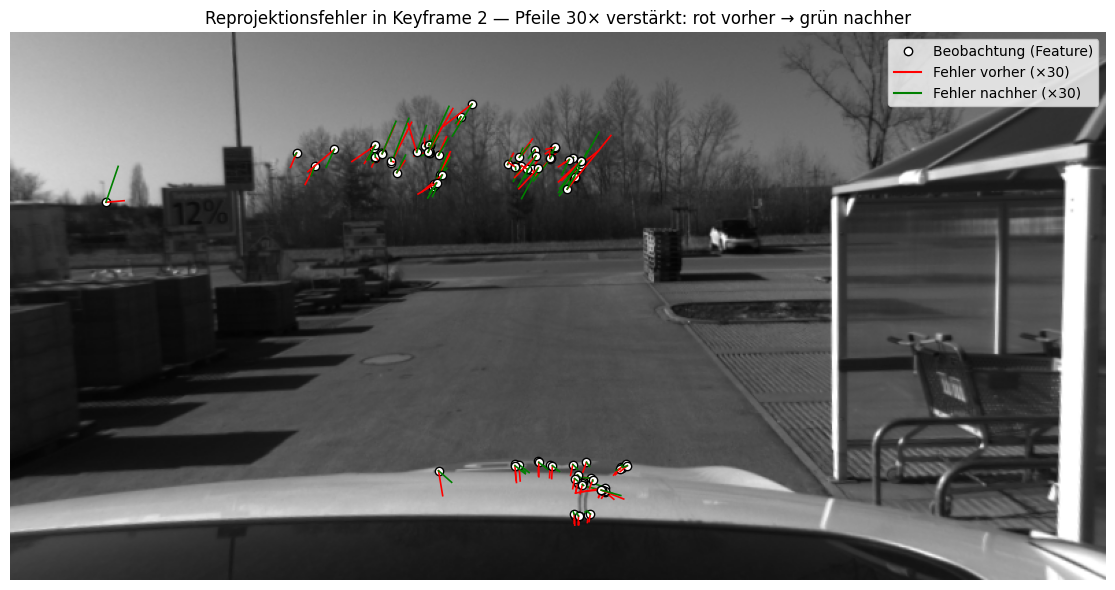

In [14]:
# Zoom-in auf ein Beispielbild: wo war der Pixel beobachtet,
# wo landet die Reprojektion vorher / nachher?

ZEIGE_FRAME = ANZAHL_KEYFRAMES - 1   # letzter Frame: hier ist der Drift am größten
MAX_PUNKTE_VIS = 100
FEHLER_SKALA = 30   # Pfeile zur Sichtbarkeit verlängern

plt.figure(figsize=(12, 6))
plt.imshow(keyframes_rgb[ZEIGE_FRAME])

anz = 0
for X, X_opt, tr in zip(landmarks, landmarks_opt, tracks_aktiv):
    kp_idx = tr[ZEIGE_FRAME]
    if kp_idx is None:
        continue
    beob = np.array(alle_kp[ZEIGE_FRAME][kp_idx].pt)
    p_v  = projiziere(X,     kam_R[ZEIGE_FRAME],     kam_t[ZEIGE_FRAME],     K)
    p_n  = projiziere(X_opt, kam_R_opt[ZEIGE_FRAME], kam_t_opt[ZEIGE_FRAME], K)

    # Vektoren skalieren, damit sub-pixel-Fehler überhaupt sichtbar sind
    p_v_vis = beob + (p_v - beob) * FEHLER_SKALA
    p_n_vis = beob + (p_n - beob) * FEHLER_SKALA

    plt.plot(beob[0], beob[1], 'wo', markersize=6, markeredgecolor='black')
    plt.plot([beob[0], p_v_vis[0]], [beob[1], p_v_vis[1]], 'r-', linewidth=1.2)
    plt.plot([beob[0], p_n_vis[0]], [beob[1], p_n_vis[1]], 'g-', linewidth=1.2)
    anz += 1
    if anz >= MAX_PUNKTE_VIS:
        break

plt.plot([], [], 'wo', markeredgecolor='black', label='Beobachtung (Feature)')
plt.plot([], [], 'r-', label=f'Fehler vorher (×{FEHLER_SKALA})')
plt.plot([], [], 'g-', label=f'Fehler nachher (×{FEHLER_SKALA})')
plt.legend(loc='upper right')
plt.title(f'Reprojektionsfehler in Keyframe {ZEIGE_FRAME} — Pfeile {FEHLER_SKALA}× verstärkt: rot vorher → grün nachher')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Zusammenfassung

```
Schritt 1: Features in allen Keyframes extrahieren     → ORB pro Frame
Schritt 2: Tracks aufbauen                             → dasselbe Feature in mehreren Frames
Schritt 3: Initialposen (Essential Matrix + PnP)       → Posen mit konsistentem Maßstab
Schritt 4: Triangulation (N-View DLT)                  → 3D-Landmarks erzeugen
Schritt 5: 3D-Visualisierung                           → die lokale Karte
Schritt 6: Reprojektionsfehler messen                  → wie schief ist die Karte?
Schritt 7: Bundle Adjustment (Levenberg-Marquardt)     → Posen + Punkte gemeinsam optimieren
Schritt 8: Vergleich vorher / nachher                  → Fehler deutlich kleiner
```

**Output:** verfeinerte Kamera-Posen + saubere 3D-Punktwolke → geht weiter als Input in **3.x Globales Mapping** (Loop-Closure, globales Bundle Adjustment, Pose-Graph).

**Was wir bewusst ausgelassen haben** (gehört zum echten lokalen Mapping, hier didaktisch vereinfacht):
- Keyframe-Auswahl-Heuristiken (wann ist ein Frame ein neuer Keyframe?)
- Robuste Kosten (Huber-Loss) statt L2 — wichtig bei verbleibenden Outliern
- Sparsity-Pattern in der Jacobi-Matrix — macht BA in echten Systemen erst skalierbar
- Marginalisierung alter Keyframes (Sliding-Window)
- Drift-Kompensation und Loop-Closure (kommt im globalen Mapping)